# Serial Section Alignment

This notebook aligns a folder of serially-cut .ndpi H&E whole-slide images using one-section-per-slide ordering.

For range-based multi-section files (for example `*_Sec_1-9.ndpi`) and the new section-manifest format (`section_bbox_manifest.json`), use `align_serial_sections_LC_CODA.ipynb`.

**Algorithm:**
1. Discover slides and sort by trailing number in filename
2. Start from the middle slide (anchor)
3. Align outward: middle → end, then middle → start
4. For each pair: affine registration (ORB), then sparse-grid elastic (phase correlation)
5. If tissue IoU < threshold, skip up to N damaged sections

**Outputs saved (in `OUTPUT_FOLDER`):**
```
OUTPUT_FOLDER/
├── aligned/
│   └── {fname}.png          ← registered H&E images
├── masks/
│   └── {fname}.png          ← tissue masks (if save_masks=True)
├── transforms/
│   ├── affine/
│   │   └── {fname}.pkl      ← affine matrix + metadata
│   └── elastic/
│       └── {fname}.npy      ← dense displacement field
└── alignment_results.json   ← IoU scores and metadata
```

**Requirements:** `pyvips`, `opencv-python`, `numpy`, `tifffile`, `scipy`, `matplotlib`

In [6]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ALIGNMENT_DIR = os.path.dirname(os.path.abspath("__file__"))
if ALIGNMENT_DIR not in sys.path:
    sys.path.insert(0, ALIGNMENT_DIR)

from alignment_pipeline import align_serial_sections, discover_slides, load_transform
from registration import read_ndpi_level, tissue_mask, compute_iou

## Configuration

In [7]:
# User settings
SLIDE_FOLDER  = "/home/donald/Desktop/shelter_server_donald/data/DDLPS_CODA/sample0"
OUTPUT_FOLDER = os.path.join(SLIDE_FOLDER, "alignment")

# Registration parameters
LEVEL          = 5          # Pyramid level (higher = faster; level 5 ≈ 32× downsampled)
IOU_THRESHOLD  = 0.85       # Min IoU to accept an alignment
MAX_SKIP       = 2          # Max consecutive damaged slides to test paired affine IoU score (forward and back if possible)
G_THRESH       = 150        # Green-channel tissue threshold (170 usually is good)
AFFINE_METHOD  = "ORB"      # ORB: fast feature-based affine

# Elastic registration (sparse-grid phase correlation, port of MATLAB calculate_elastic_registration)
DO_ELASTIC     = True
TILE_SIZE      = 800        # sz:  size of each registration tile (px at working level)
BUFFER         = 400        # bf:  padding around image before tiling
GRID_SPACING   = 100        # di:  distance between tile centres
TISSUE_CUTOFF  = 0.15       # min fraction of tissue in a tile to attempt registration

# NEW — stronger warping controls
ELASTIC_PASSES = 3          # more coarse-to-fine passes (was default 3)
RBF_SMOOTHING  = 0.05       # sharper field (was default 0.1)
KEEP_IF_IMPROVES = True     # auto-revert any pass that lowers grayscale NCC

# Canvas padding: adds a white border around the anchor (and all moving images) before
# registration.  Increase this if aligned images are cropped too aggressively at the edges.
# Units: pixels at LEVEL resolution.  E.g. 50 ≈ 50*32 = 1600 µm at level 5.
PADDING        = 200          # 0 = no padding (original behaviour)

EXTENSION      = ".ndpi"

## Preview slides

In [8]:
slides = discover_slides(SLIDE_FOLDER, EXTENSION)
print(f"Found {len(slides)} slides:")
for i, s in enumerate(slides):
    print(f"  [{i}] {Path(s).name}")

mid = len(slides) // 2
print(f"\nAnchor (middle): [{mid}] {Path(slides[mid]).name}")

Found 50 slides:
  [0] CODA_LDD-091_HE_slide-01 - 2026-06-11 16.40.49.ndpi
  [1] CODA_LDD-091_HE_slide-03 - 2026-06-11 16.46.25.ndpi
  [2] CODA_LDD-091_HE_slide-05 - 2026-06-11 16.52.04.ndpi
  [3] CODA_LDD-091_HE_slide-07 - 2026-06-11 16.58.20.ndpi
  [4] CODA_LDD-091_HE_slide-09 - 2026-06-11 17.04.42.ndpi
  [5] CODA_LDD-091_HE_slide-11 - 2026-06-11 17.10.12.ndpi
  [6] CODA_LDD-091_HE_slide-13 - 2026-06-11 17.15.44.ndpi
  [7] CODA_LDD-091_HE_slide-15 - 2026-06-11 17.21.46.ndpi
  [8] CODA_LDD-091_HE_slide-17 - 2026-06-11 17.27.19.ndpi
  [9] CODA_LDD-091_HE_slide-19 - 2026-06-11 17.33.14.ndpi
  [10] CODA_LDD-091_HE_slide-21 - 2026-06-11 17.38.58.ndpi
  [11] CODA_LDD-091_HE_slide-23 - 2026-06-11 17.44.28.ndpi
  [12] CODA_LDD-091_HE_slide-25 - 2026-06-11 17.50.17.ndpi
  [13] CODA_LDD-091_HE_slide-27 - 2026-06-11 17.56.26.ndpi
  [14] CODA_LDD-091_HE_slide-29 - 2026-06-11 18.02.18.ndpi
  [15] CODA_LDD-091_HE_slide-31 - 2026-06-11 18.08.14.ndpi
  [16] CODA_LDD-091_HE_slide-33 - 2026-06-11 18.1

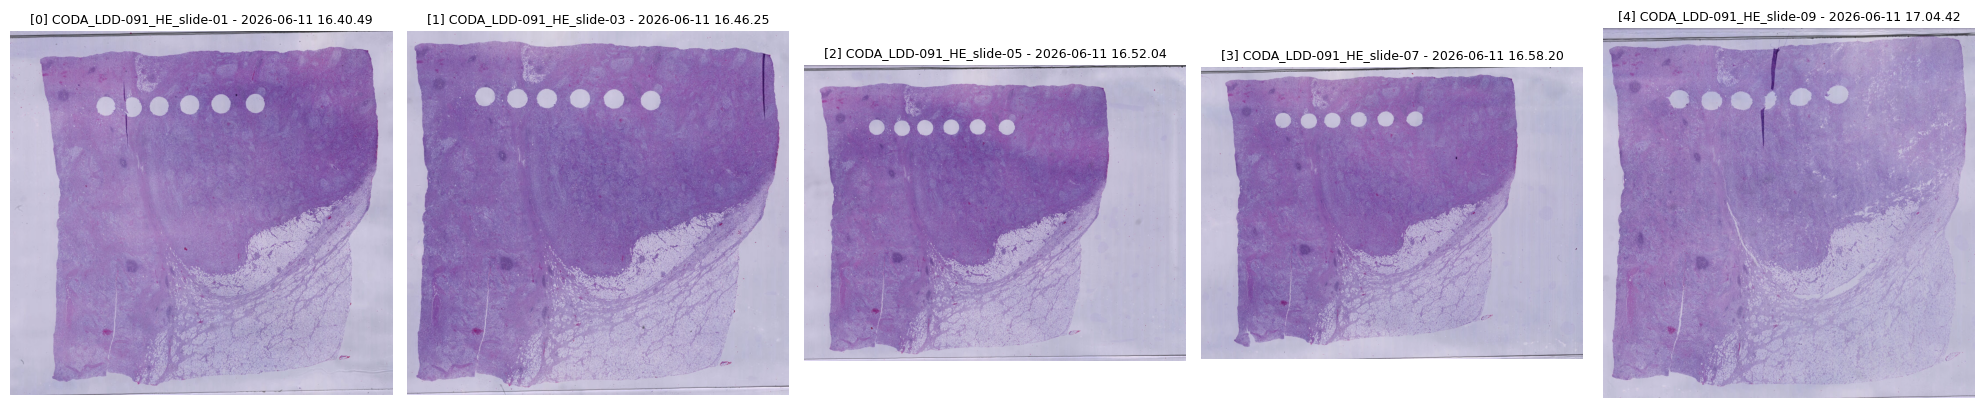

In [9]:
# Show thumbnails of first n slides
n = min(len(slides), 5)
cols = 5
rows = (n + cols - 1) // cols  # Calculate rows needed

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten()  # Flatten to 1D for easy indexing

thumb_level = min(LEVEL + 2, 6)
for i, s in enumerate(slides[:n]):
    try:
        img = read_ndpi_level(s, level=thumb_level)
    except Exception:
        img = read_ndpi_level(s, level=LEVEL)
    axes[i].imshow(img)
    title = f"[{i}] {Path(s).stem}"
    if i == mid:
        title += " (anchor)"
    axes[i].set_title(title, fontsize=9)
    axes[i].axis("off")

# Hide unused axes
for i in range(n, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()


## Run alignment

In [ ]:
results = align_serial_sections(
    slide_folder=SLIDE_FOLDER,
    output_folder=OUTPUT_FOLDER,
    level=LEVEL,
    iou_threshold=IOU_THRESHOLD,
    max_skip=MAX_SKIP,
    g_thresh=G_THRESH,
    affine_method=AFFINE_METHOD,
    do_elastic=DO_ELASTIC,
    tile_size=TILE_SIZE,
    buffer=BUFFER,
    grid_spacing=GRID_SPACING,
    tissue_cutoff=TISSUE_CUTOFF,
    elastic_passes=ELASTIC_PASSES,
    rbf_smoothing=RBF_SMOOTHING,
    keep_if_improves=KEEP_IF_IMPROVES,
    extension=EXTENSION,
    padding=PADDING,
    save_aligned=True,
    save_masks=True,
    verbose=True,
)

Found 50 slides in /home/donald/Desktop/shelter_server_donald/data/DDLPS_CODA/sample0

Anchor slide (middle): [25] CODA_LDD-091_HE_slide-51 - 2026-06-11 19.06.53.ndpi
  Anchor padded: (1568, 1680) -> (1968, 2080) (padding=200px)

FORWARD PASS: indices 26..49

Aligning [26] CODA_LDD-091_HE_slide-53 - 2026-06-11 19.12.07.ndpi -> reference [25]
    [affine/ORB] estimating transform ...
    [affine/ORB] done (score=0.7286)
    [affine] IoU = 0.8808
    [elastic] tile=800 buf=400 spacing=100 passes=3 smoothing=0.05 ...
    [elastic-mp] start NCC=0.4630
    [elastic-mp] pass 1/3 tile=800 spacing=100 NCC 0.4630->0.5266 (+0.0636) [keep]
    [elastic-mp] pass 2/3 tile=560 spacing=60 NCC 0.5266->0.5506 (+0.0240) [keep]
    [elastic-mp] pass 3/3 tile=392 spacing=36 NCC 0.5506->0.5669 (+0.0162) [keep]
    [elastic] done (IoU 0.8808 -> 0.9213)
  OK accepted (IoU=0.9213)

Aligning [27] CODA_LDD-091_HE_slide-55 - 2026-06-12 10.38.57.ndpi -> reference [26]
    [affine/ORB] estimating transform ...
   

## Inspect saved transforms

In [ ]:
affine_dir = Path(OUTPUT_FOLDER) / "transforms" / "affine"
pkl_files = sorted(affine_dir.glob("*.pkl"))

print(f"Found {len(pkl_files)} saved transforms in {affine_dir}\n")
print(f"{'File':<50} {'Slide':>6} {'Ref':>5} {'Level':>6} {'Has affine':>11} {'Has elastic':>12} {'Notes'}")
print("-" * 110)
for p in pkl_files:
    t = load_transform(str(affine_dir), p.stem)
    has_aff = "yes" if t["affine_matrix"] is not None else "no"
    has_ela = "yes" if t["elastic_transform"] is not None else "no"
    print(f"{p.name:<50} {t['slide_index']:>6} {t['reference_index']:>5} "
          f"{t['level']:>6} {has_aff:>11} {has_ela:>12}  {t['notes']}")

## Visualize results

In [ ]:
import tifffile

out_dir = Path(OUTPUT_FOLDER)

print("\nAlignment Summary")
print("=" * 50)
for r in sorted(results, key=lambda x: x.index):
    status = "SKIP" if r.skipped else "OK  "
    print(f"[{r.index:3d}] {status}  IoU={r.iou:.4f}  ref={r.reference_index}  {r.notes}")

In [ ]:
# Plot IoU across slides
indices = [r.index for r in results if not r.skipped]
ious    = [r.iou   for r in results if not r.skipped]

plt.figure(figsize=(10, 3))
plt.bar(indices, ious, color="steelblue", edgecolor="navy")
plt.axhline(IOU_THRESHOLD, color="red", linestyle="--", label=f"threshold={IOU_THRESHOLD}")
plt.xlabel("Slide index")
plt.ylabel("Tissue IoU")
plt.title("Registration quality (tissue IoU with reference)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Show aligned images side-by-side (reads from aligned/ subfolder)
aligned_files = sorted((out_dir / "aligned").glob("*.png"))
n_show = min(len(aligned_files), 8)

fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4))
if n_show == 1:
    axes = [axes]

from PIL import Image as PILImage
for ax, f in zip(axes, aligned_files[:n_show]):
    img = np.array(PILImage.open(str(f)))
    ax.imshow(img)
    ax.set_title(f.stem, fontsize=9)
    ax.axis("off")

plt.suptitle("Aligned sections", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Overlay: blend adjacent aligned sections to visually check registration
from PIL import Image as PILImage
if len(aligned_files) >= 2:
    n_pairs = min(len(aligned_files) - 1, 4)
    fig, axes = plt.subplots(1, n_pairs, figsize=(5 * n_pairs, 5))
    if n_pairs == 1:
        axes = [axes]

    for k in range(n_pairs):
        img_a = np.array(PILImage.open(str(aligned_files[k])))
        img_b = np.array(PILImage.open(str(aligned_files[k + 1])))
        h = min(img_a.shape[0], img_b.shape[0])
        w = min(img_a.shape[1], img_b.shape[1])
        blend = (
            img_a[:h, :w].astype(float) * 0.5 + img_b[:h, :w].astype(float) * 0.5
        ).astype(np.uint8)
        axes[k].imshow(blend)
        axes[k].set_title(f"{aligned_files[k].stem} + {aligned_files[k+1].stem}", fontsize=8)
        axes[k].axis("off")

    plt.suptitle("Blended overlays (adjacent pairs)", fontsize=13)
    plt.tight_layout()
    plt.show()